In [1]:
"""
Assignment 1: Reinforcement Learning from Human Feedback (RLHF)
Notebook: 06_evaluation.ipynb

Purpose:
This notebook evaluates and compares all major models produced in the RLHF pipeline:
the base model, the SFT model, the PPO-HH model, and the PPO-HelpSteer2 model.
It reports automatic metrics, reward-based comparisons, and pairwise preference-style
results to analyse the impact of reward modelling and PPO training.

Summary of sections:
1. Environment setup and package imports
   - Imports evaluation libraries, metrics, plotting tools, and utility functions.

2. Loading models and tokenizers
   - Loads the base model, SFT model, PPO-HH model, PPO-HelpSteer2 model,
     and reward models if needed for scoring.

3. Evaluation dataset preparation
   - Loads and prepares prompts / references used for evaluation.

4. Response generation
   - Generates outputs from each model under a consistent evaluation setting.

5. Automatic metric computation
   - Computes metrics such as ROUGE, BERTScore, response length, and any other selected metrics.

6. Reward-based evaluation
   - Scores model outputs using the trained reward models to estimate preference quality.

7. Pairwise comparison analysis
   - Compares models against each other, such as PPO variants versus SFT,
     using reward-model-based preference proxies.

8. Results aggregation and visualization
   - Builds summary tables, plots, and comparison outputs for the report and slides.

9. Saving outputs
   - Saves evaluation tables, generated outputs, logs, and visualisations.

Main output:
- Final evaluation results comparing base, SFT, PPO-HH, and PPO-HelpSteer2 models.
"""

'\nAssignment 1: Reinforcement Learning from Human Feedback (RLHF)\nNotebook: 06_evaluation.ipynb\n\nPurpose:\nThis notebook evaluates and compares all major models produced in the RLHF pipeline:\nthe base model, the SFT model, the PPO-HH model, and the PPO-HelpSteer2 model.\nIt reports automatic metrics, reward-based comparisons, and pairwise preference-style\nresults to analyse the impact of reward modelling and PPO training.\n\nSummary of sections:\n1. Environment setup and package imports\n   - Imports evaluation libraries, metrics, plotting tools, and utility functions.\n\n2. Loading models and tokenizers\n   - Loads the base model, SFT model, PPO-HH model, PPO-HelpSteer2 model,\n     and reward models if needed for scoring.\n\n3. Evaluation dataset preparation\n   - Loads and prepares prompts / references used for evaluation.\n\n4. Response generation\n   - Generates outputs from each model under a consistent evaluation setting.\n\n5. Automatic metric computation\n   - Computes m

In [3]:
from google.colab import drive
drive.mount('/content/drive')

SFT_ADAPTER_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/sft_qwen25_05b_base"
RM_HH_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/rm_hh"
RM_HELPSTEER2_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/rm_helpsteer2"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Install packages

# Install packages

!pip -q install -U \
  "sympy==1.12" \
  "transformers==4.45.2" \
  "trl==0.11.4" \
  "peft==0.12.0" \
  "accelerate==0.34.2" \
  "datasets==2.21.0" \
  "evaluate==0.4.3" \
  "rouge_score" \
  "bert_score" \
  "scikit-learn" \
  "matplotlib" \
  "pandas"



In [6]:
!pip uninstall -y torchvision torchaudio

In [5]:
import importlib.util
print("torchvision installed:", importlib.util.find_spec("torchvision") is not None)
print("torchaudio installed:", importlib.util.find_spec("torchaudio") is not None)

torchvision installed: False
torchaudio installed: False


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
sympy: 1.12
peft version: 0.12.0
transformers version: 4.45.2
trl version: 0.11.4
accelerate version: 0.34.2
Device: cuda

SFT_ADAPTER_PATH: /content/drive/MyDrive/rlhf_assignment_outputs/sft_qwen25_05b_base
Exists: True
  checkpoint-100
  checkpoint-125
  README.md
  adapter_model.safetensors
  tokenizer.json
  training_args.bin
  chat_template.jinja
  tokenizer_config.json
  adapter_config.json

RM_HH_PATH: /content/drive/MyDrive/rlhf_assignment_outputs/rm_hh
Exists: True
  checkpoint-50
  checkpoint-58
  tokenizer_config.json
  training_args.bin
  adapter_model.safetensors
  tokenizer.json
  README.md
  adapter_config.json

RM_HELPSTEER2_PATH: /content/drive/MyDrive/rlhf_assignment_outputs/rm_helpsteer2
Exists: True
  README.md
  config.json
  model.safetensors
  tokenizer_config.json
  training_args.bin
  tokenizer.json
  checkpoint-32
  checkpoint-4

PPO

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


All generation models loaded successfully.

Loading RM-HH...
Loading RM-HelpSteer2...
All reward models loaded successfully.

Generating base outputs...


Generating:   0%|          | 0/25 [00:00<?, ?it/s]

Generating SFT outputs...


...

Generating PPO-HelpSteer2 outputs...


Generating:   0%|          | 0/25 [00:00<?, ?it/s]


Generation completed.
Reward scoring completed.


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Summary table:
     model    rouge1    rouge2    rougeL  bertscore_chosen_f1  \
0     base  0.233575  0.052406  0.130425             0.834027   
1      sft  0.236230  0.054941  0.132496             0.834946   
2   ppo_hh  0.231314  0.051585  0.128996             0.833594   
3  ppo_hs2  0.229080  0.052428  0.128724             0.833032   

   bertscore_rejected_f1  preference_proxy_win_rate  mean_rm_hh_score  \
0               0.833245                       0.55         -0.006104   
1               0.834773                       0.53         -0.006116   
2               0.834305                       0.49         -0.007373   
3               0.833118                       0.54         -0.007068   

   mean_rm_hs2_score  mean_output_words  
0           0.041974             104.49  
1           0.039344             104.40  
2           0.041195             103.63  
3           0.041222             104.76  

Pairwise vs SFT:
  challenger vs_model  win_rate_under_rm_hh  win_rate_under_rm_h

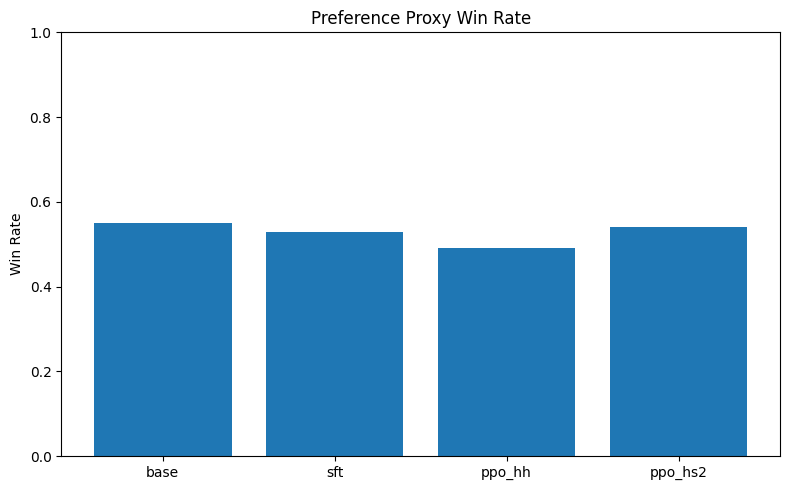

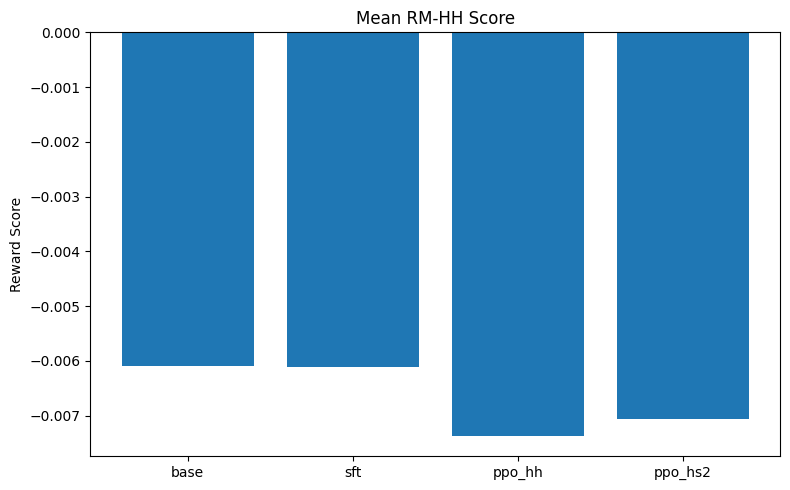

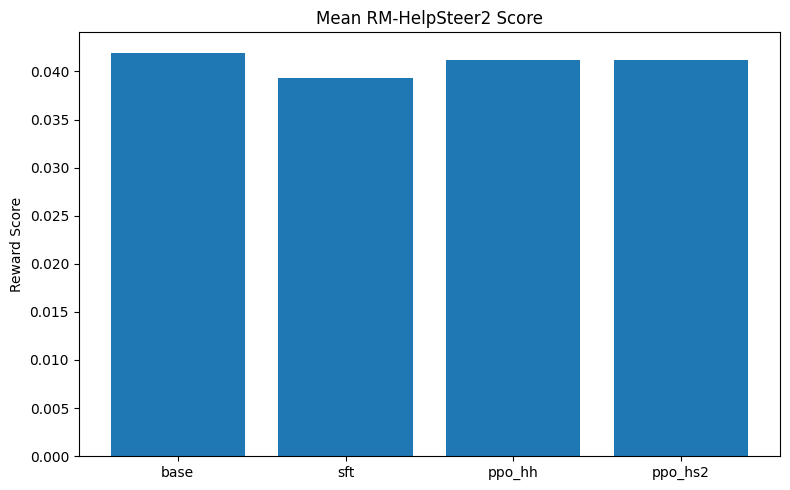

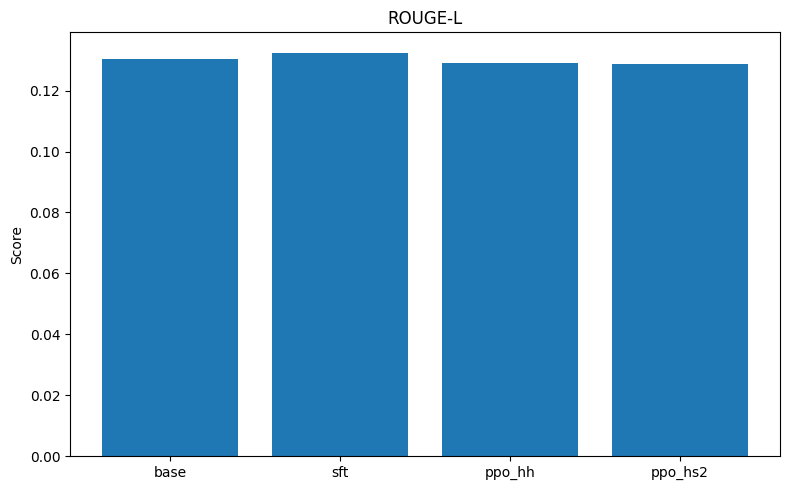


Evaluation complete.


In [8]:
# Import Libraries

import os
import gc
import json
import random
import warnings
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import evaluate
import shutil

from collections import defaultdict
from tqdm.auto import tqdm
from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
)
from peft import PeftModel, LoraConfig

warnings.filterwarnings("ignore")


# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')


# Paths

BASE_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

SFT_ADAPTER_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/sft_qwen25_05b_base"
RM_HH_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/rm_hh"
RM_HELPSTEER2_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/rm_helpsteer2"

PPO_HH_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/ppo_hh"
PPO_HELPSTEER2_PATH = "/content/drive/MyDrive/rlhf_assignment_outputs/ppo_helpsteer2"

OUTPUT_DIR = "./outputs/evaluation"

os.makedirs("./outputs", exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Version Check

import sympy
import peft
import transformers
import trl
import accelerate

print("sympy:", sympy.__version__)
print("peft version:", peft.__version__)
print("transformers version:", transformers.__version__)
print("trl version:", trl.__version__)
print("accelerate version:", accelerate.__version__)


# Configuration

SEED = 42
MAX_INPUT_LENGTH = 256
MAX_NEW_TOKENS = 100
MAX_RM_LENGTH = 512
HH_EVAL_SAMPLES = 50
HS2_EVAL_SAMPLES = 50
GEN_BATCH_SIZE = 4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print("Device:", device)


# Show Available Files

for path_name, path_value in {
    "SFT_ADAPTER_PATH": SFT_ADAPTER_PATH,
    "RM_HH_PATH": RM_HH_PATH,
    "RM_HELPSTEER2_PATH": RM_HELPSTEER2_PATH,
    "PPO_HH_PATH": PPO_HH_PATH,
    "PPO_HELPSTEER2_PATH": PPO_HELPSTEER2_PATH,
}.items():
    print(f"\n{path_name}: {path_value}")
    print("Exists:", os.path.exists(path_value))
    if os.path.exists(path_value):
        for f in os.listdir(path_value):
            print(" ", f)


# Metrics

rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")


# Helper Function: sanitize LoRA config

def sanitize_lora_config(config_path):
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"adapter_config.json not found at: {config_path}")

    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    allowed_keys = set(inspect.signature(LoraConfig.__init__).parameters.keys())
    allowed_keys.discard("self")

    removed = {}
    clean_cfg = {}

    for k, v in cfg.items():
        if k in allowed_keys:
            clean_cfg[k] = v
        else:
            removed[k] = v

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(clean_cfg, f, indent=2)

    return removed, clean_cfg


# Sanitize PEFT configs where applicable

for maybe_adapter_path in [SFT_ADAPTER_PATH, RM_HH_PATH, PPO_HH_PATH, PPO_HELPSTEER2_PATH]:
    cfg_path = os.path.join(maybe_adapter_path, "adapter_config.json")
    if os.path.exists(cfg_path):
        removed, clean = sanitize_lora_config(cfg_path)
        print(f"\nSanitized: {cfg_path}")
        print("Removed unsupported keys:", list(removed.keys()))
        print("Remaining keys:", list(clean.keys()))


# Helper Functions: prompts and dataset preparation

def build_sft_style_prompt(instruction):
    instruction = str(instruction).strip()
    return f"Instruction: {instruction}\n\nResponse:"

def split_hh_prompt_and_answers(example):
    chosen = str(example["chosen"])
    rejected = str(example["rejected"])

    marker = "\n\nAssistant:"
    idx_chosen = chosen.rfind(marker)
    idx_rejected = rejected.rfind(marker)

    if idx_chosen != -1:
        prompt_part = chosen[:idx_chosen].strip()
        chosen_resp = chosen[idx_chosen + len(marker):].strip()
    else:
        prompt_part = chosen.strip()
        chosen_resp = ""

    if idx_rejected != -1:
        rejected_resp = rejected[idx_rejected + len(marker):].strip()
    else:
        rejected_resp = ""

    prompt_part = prompt_part.replace("\n\nHuman:", "").strip()

    return {
        "source": "hh",
        "instruction": prompt_part,
        "chosen": chosen_resp,
        "rejected": rejected_resp
    }

def build_helpsteer2_pairs(split_ds):
    groups = defaultdict(list)

    for ex in split_ds:
        prompt = ex.get("prompt", "")
        response = ex.get("response", "")
        helpfulness = ex.get("helpfulness", None)

        if prompt is None or response is None or helpfulness is None:
            continue

        groups[str(prompt)].append({
            "response": str(response),
            "helpfulness": float(helpfulness)
        })

    rows = []
    for prompt, candidates in groups.items():
        if len(candidates) < 2:
            continue

        candidates = sorted(candidates, key=lambda x: x["helpfulness"], reverse=True)
        best = candidates[0]
        worst = candidates[-1]

        if best["helpfulness"] == worst["helpfulness"]:
            continue

        rows.append({
            "source": "helpsteer2",
            "instruction": str(prompt).strip(),
            "chosen": str(best["response"]).strip(),
            "rejected": str(worst["response"]).strip()
        })

    return Dataset.from_list(rows)


# Load Evaluation Datasets

hh_eval = load_dataset("Anthropic/hh-rlhf", split="test")
hh_eval = hh_eval.shuffle(seed=SEED).select(range(min(HH_EVAL_SAMPLES, len(hh_eval))))
hh_eval = hh_eval.map(split_hh_prompt_and_answers)
hh_eval = hh_eval.remove_columns([c for c in hh_eval.column_names if c not in ["source", "instruction", "chosen", "rejected"]])

raw_hs2 = load_dataset("nvidia/HelpSteer2")
hs2_eval_raw = raw_hs2["validation"] if "validation" in raw_hs2 else raw_hs2["train"]
hs2_eval = build_helpsteer2_pairs(hs2_eval_raw)
hs2_eval = hs2_eval.shuffle(seed=SEED).select(range(min(HS2_EVAL_SAMPLES, len(hs2_eval))))

eval_dataset = concatenate_datasets([hh_eval, hs2_eval]).shuffle(seed=SEED)
eval_df = eval_dataset.to_pandas().reset_index(drop=True)

eval_df["formatted_prompt"] = eval_df["instruction"].apply(build_sft_style_prompt)

print("\nEvaluation size:", len(eval_df))
print(eval_df.head(3))


# Helper Functions: model loading

def prepare_tokenizer(model_name_or_path):
    tok = AutoTokenizer.from_pretrained(model_name_or_path, use_fast=True)
    if tok.pad_token is None:
        if tok.eos_token is not None:
            tok.pad_token = tok.eos_token
        else:
            tok.add_special_tokens({"pad_token": "[PAD]"})
    tok.padding_side = "left"
    return tok

def load_base_generation_model():
    tok = prepare_tokenizer(BASE_MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_NAME,
        torch_dtype=dtype,
        device_map="auto"
    )
    model.eval()
    return model, tok

def load_peft_generation_model(adapter_path):
    tok = prepare_tokenizer(BASE_MODEL_NAME)
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_NAME,
        torch_dtype=dtype,
        device_map="auto"
    )
    model = PeftModel.from_pretrained(base_model, adapter_path)
    model.eval()
    return model, tok

def load_saved_generation_model(path_value):
    if os.path.exists(os.path.join(path_value, "adapter_config.json")):
        return load_peft_generation_model(path_value)

    tok = prepare_tokenizer(path_value)
    model = AutoModelForCausalLM.from_pretrained(
        path_value,
        torch_dtype=dtype,
        device_map="auto"
    )
    model.eval()
    return model, tok

def load_rm_hh():
    tok = AutoTokenizer.from_pretrained("distilbert-base-uncased", use_fast=True)
    if tok.pad_token is None:
        if tok.sep_token is not None:
            tok.pad_token = tok.sep_token
        else:
            tok.add_special_tokens({"pad_token": "[PAD]"})

    base_model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=1
    ).to(device)

    model = PeftModel.from_pretrained(base_model, RM_HH_PATH)
    model = model.to(device)
    model.eval()
    return model, tok

def load_rm_hs2():
    tok = AutoTokenizer.from_pretrained(RM_HELPSTEER2_PATH, use_fast=True)
    if tok.pad_token is None:
        if tok.sep_token is not None:
            tok.pad_token = tok.sep_token
        elif tok.eos_token is not None:
            tok.pad_token = tok.eos_token
        else:
            tok.add_special_tokens({"pad_token": "[PAD]"})

    model = AutoModelForSequenceClassification.from_pretrained(
        RM_HELPSTEER2_PATH
    ).to(device)
    model.eval()
    return model, tok


# Load Generation Models

print("\nLoading base model...")
base_model, base_tokenizer = load_base_generation_model()

print("Loading SFT model...")
sft_model, sft_tokenizer = load_peft_generation_model(SFT_ADAPTER_PATH)

print("Loading PPO-HH model...")
ppo_hh_model, ppo_hh_tokenizer = load_saved_generation_model(PPO_HH_PATH)

print("Loading PPO-HelpSteer2 model...")
ppo_hs2_model, ppo_hs2_tokenizer = load_saved_generation_model(PPO_HELPSTEER2_PATH)

print("All generation models loaded successfully.")


# Load Reward Models

print("\nLoading RM-HH...")
rm_hh_model, rm_hh_tokenizer = load_rm_hh()

print("Loading RM-HelpSteer2...")
rm_hs2_model, rm_hs2_tokenizer = load_rm_hs2()

print("All reward models loaded successfully.")


# Helper Functions: generation and scoring

def generate_outputs(model, tokenizer, prompts, batch_size=4):
    outputs_all = []

    for i in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
        batch_prompts = prompts[i:i+batch_size]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LENGTH
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=True,
                temperature=0.3,
                top_p=0.9,
                repetition_penalty=1.15,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        input_lengths = inputs["attention_mask"].sum(dim=1).tolist()

        for j, seq in enumerate(outputs):
            continuation = seq[int(input_lengths[j]):]
            text = tokenizer.decode(continuation, skip_special_tokens=True).strip()
            outputs_all.append(text)

    return outputs_all

def build_rm_text(instruction, response):
    return f"Human: {str(instruction).strip()}\n\nAssistant: {str(response).strip()}"

def score_with_rm(model, tokenizer, texts):
    scores = []

    for i in range(0, len(texts), 8):
        batch = texts[i:i+8]
        inputs = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_RM_LENGTH,
            return_tensors="pt"
        )

        if "token_type_ids" in inputs:
            inputs.pop("token_type_ids")

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits.squeeze(-1)

        if logits.dim() == 0:
            logits = logits.unsqueeze(0)

        scores.extend(logits.detach().cpu().numpy().tolist())

    return np.array(scores)


# Generate Outputs

prompts = eval_df["formatted_prompt"].tolist()

print("\nGenerating base outputs...")
eval_df["base_output"] = generate_outputs(base_model, base_tokenizer, prompts, batch_size=GEN_BATCH_SIZE)

print("Generating SFT outputs...")
eval_df["sft_output"] = generate_outputs(sft_model, sft_tokenizer, prompts, batch_size=GEN_BATCH_SIZE)

print("Generating PPO-HH outputs...")
eval_df["ppo_hh_output"] = generate_outputs(ppo_hh_model, ppo_hh_tokenizer, prompts, batch_size=GEN_BATCH_SIZE)

print("Generating PPO-HelpSteer2 outputs...")
eval_df["ppo_hs2_output"] = generate_outputs(ppo_hs2_model, ppo_hs2_tokenizer, prompts, batch_size=GEN_BATCH_SIZE)

print("\nGeneration completed.")


# Score All Outputs with Reward Models

for col in ["base_output", "sft_output", "ppo_hh_output", "ppo_hs2_output"]:
    texts = [build_rm_text(inst, resp) for inst, resp in zip(eval_df["instruction"], eval_df[col])]
    eval_df[f"{col}_rm_hh"] = score_with_rm(rm_hh_model, rm_hh_tokenizer, texts)
    eval_df[f"{col}_rm_hs2"] = score_with_rm(rm_hs2_model, rm_hs2_tokenizer, texts)

print("Reward scoring completed.")


# Automatic Metrics

summary_rows = []

model_columns = {
    "base": "base_output",
    "sft": "sft_output",
    "ppo_hh": "ppo_hh_output",
    "ppo_hs2": "ppo_hs2_output"
}

for model_name, pred_col in model_columns.items():
    preds = eval_df[pred_col].fillna("").tolist()
    refs = eval_df["chosen"].fillna("").tolist()
    rejected_refs = eval_df["rejected"].fillna("").tolist()

    rouge_scores = rouge_metric.compute(
        predictions=preds,
        references=refs,
        use_stemmer=True
    )

    bert_chosen = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="en"
    )

    bert_rejected = bertscore_metric.compute(
        predictions=preds,
        references=rejected_refs,
        lang="en"
    )

    chosen_f1 = np.array(bert_chosen["f1"])
    rejected_f1 = np.array(bert_rejected["f1"])

    preference_proxy = float((chosen_f1 > rejected_f1).mean())

    summary_rows.append({
        "model": model_name,
        "rouge1": float(rouge_scores["rouge1"]),
        "rouge2": float(rouge_scores["rouge2"]),
        "rougeL": float(rouge_scores["rougeL"]),
        "bertscore_chosen_f1": float(chosen_f1.mean()),
        "bertscore_rejected_f1": float(rejected_f1.mean()),
        "preference_proxy_win_rate": preference_proxy,
        "mean_rm_hh_score": float(eval_df[f"{pred_col}_rm_hh"].mean()),
        "mean_rm_hs2_score": float(eval_df[f"{pred_col}_rm_hs2"].mean()),
        "mean_output_words": float(np.mean([len(str(x).split()) for x in preds]))
    })

summary_df = pd.DataFrame(summary_rows)
print("\nSummary table:")
print(summary_df)


# Pairwise Comparison vs SFT

pairwise_rows = []

for challenger in ["base", "ppo_hh", "ppo_hs2"]:
    chal_col = model_columns[challenger]
    sft_col = model_columns["sft"]

    hh_win = float((eval_df[f"{chal_col}_rm_hh"] > eval_df[f"{sft_col}_rm_hh"]).mean())
    hs2_win = float((eval_df[f"{chal_col}_rm_hs2"] > eval_df[f"{sft_col}_rm_hs2"]).mean())

    pairwise_rows.append({
        "challenger": challenger,
        "vs_model": "sft",
        "win_rate_under_rm_hh": hh_win,
        "win_rate_under_rm_hs2": hs2_win,
        "mean_rm_hh_delta": float((eval_df[f"{chal_col}_rm_hh"] - eval_df[f"{sft_col}_rm_hh"]).mean()),
        "mean_rm_hs2_delta": float((eval_df[f"{chal_col}_rm_hs2"] - eval_df[f"{sft_col}_rm_hs2"]).mean()),
    })

pairwise_df = pd.DataFrame(pairwise_rows)
print("\nPairwise vs SFT:")
print(pairwise_df)


# Save Results

eval_df.to_csv(f"{OUTPUT_DIR}/all_generations.csv", index=False)
summary_df.to_csv(f"{OUTPUT_DIR}/evaluation_summary.csv", index=False)
pairwise_df.to_csv(f"{OUTPUT_DIR}/pairwise_vs_sft.csv", index=False)

with open(f"{OUTPUT_DIR}/qualitative_examples.jsonl", "w", encoding="utf-8") as f:
    for i in range(min(20, len(eval_df))):
        row = eval_df.iloc[i].to_dict()
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("\nSaved evaluation files to:", OUTPUT_DIR)


# Copy Evaluation Folder to Drive

drive_eval_path = "/content/drive/MyDrive/rlhf_assignment_outputs/evaluation"

if os.path.exists(drive_eval_path):
    shutil.rmtree(drive_eval_path)

shutil.copytree(OUTPUT_DIR, drive_eval_path)

print("Copied evaluation folder to Drive:", drive_eval_path)


# Plots

plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["preference_proxy_win_rate"])
plt.title("Preference Proxy Win Rate")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_preference_proxy_win_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["mean_rm_hh_score"])
plt.title("Mean RM-HH Score")
plt.ylabel("Reward Score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_mean_rm_hh_score.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["mean_rm_hs2_score"])
plt.title("Mean RM-HelpSteer2 Score")
plt.ylabel("Reward Score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_mean_rm_hs2_score.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["rougeL"])
plt.title("ROUGE-L")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_rougeL.png", dpi=200)
plt.show()

print("\nEvaluation complete.")

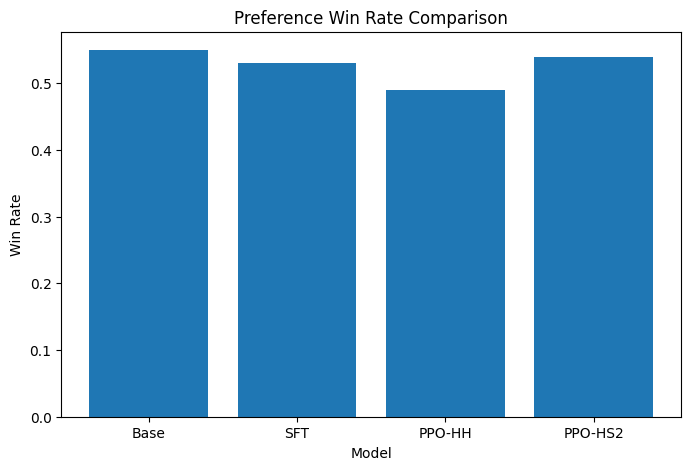

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    evaluation_df["Model"],
    evaluation_df["Preference_Win_Rate"]
)

plt.title("Preference Win Rate Comparison")
plt.ylabel("Win Rate")
plt.xlabel("Model")

plt.savefig("preference_comparison.png")

plt.show()

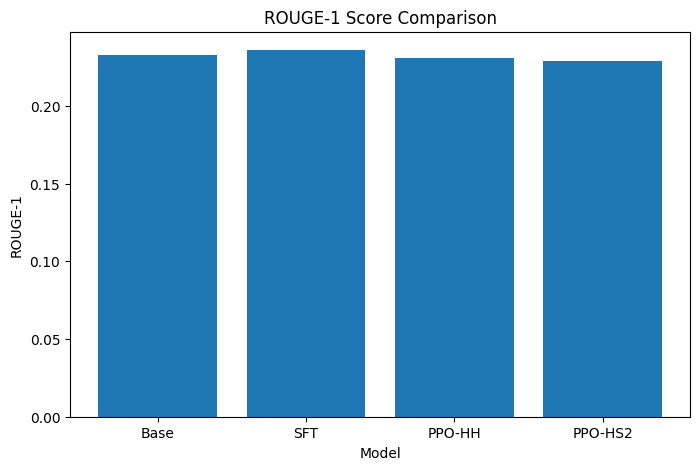

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    evaluation_df["Model"],
    evaluation_df["ROUGE1"]
)

plt.title("ROUGE-1 Score Comparison")
plt.ylabel("ROUGE-1")
plt.xlabel("Model")

plt.savefig("rouge_comparison.png")

plt.show()